In [1]:
from astropy.io import fits
import os

In [3]:
hdus = fits.open("FLATS/R/teste_flat_F3_20.fits")

In [8]:
hdus[0].data

array([[1933, 2013, 1983, ..., 1968, 1970, 1907],
       [1941, 2008, 2024, ..., 1952, 1934, 1868],
       [1987, 1988, 2037, ..., 1970, 1973, 1891],
       ...,
       [1954, 1980, 1929, ..., 1933, 1940, 1874],
       [1900, 1959, 1962, ..., 1979, 1940, 1853],
       [1867, 1932, 1924, ..., 1928, 1926, 1837]],
      shape=(1024, 1024), dtype=uint16)

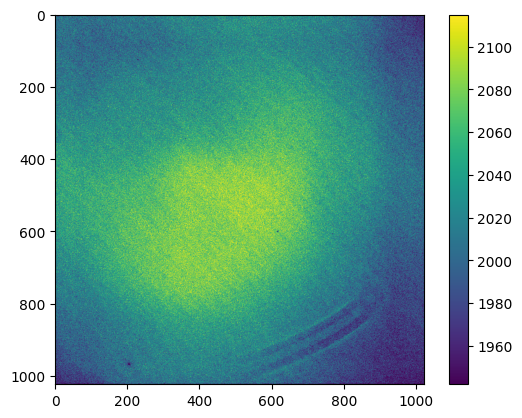

In [9]:
import matplotlib.pyplot as plt
import numpy as np 

vmin, vmax = np.percentile(hdus[0].data, [1, 99])

plt.imshow(hdus[0].data, vmin=vmin, vmax=vmax)
plt.colorbar()
plt.show()

In [11]:
files =  os.listdir("FLATS/R")

In [37]:
import os
import numpy as np
from astropy.io import fits


def make_master_flat(flat_dir, lower=0.96, upper=1.04):
    files = [
        os.path.join(flat_dir, f)
        for f in os.listdir(flat_dir)
        if f.lower().endswith((".fits", ".fit", ".fts"))
    ]

    stack = []

    for f in files:
        with fits.open(f) as hdul:
            data = hdul[0].data.astype(float)
            data /= np.nanmedian(data)
            stack.append(data)

    stack = np.array(stack)

    master = np.nanmedian(stack, axis=0)
    master /= np.nanmedian(master)

    bad_mask = (master < lower) | (master > upper)

    hdu_master = fits.PrimaryHDU(master.astype(np.float32))
    hdu_badmask = fits.PrimaryHDU(bad_mask.astype(np.uint8))

    return hdu_master, hdu_badmask

In [38]:

def create_thumbnail(data, outpath, pmin=1, pmax=99, cmap="gray"):
    vmin, vmax = np.nanpercentile(data, [pmin, pmax])

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(data, cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
    ax.axis("off")

    plt.tight_layout(pad=0)
    fig.savefig(outpath, dpi=150, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

In [39]:
bands = ["R", "I", "B", "V"]

for band in bands:
    master, bp_mask = make_master_flat(f"FLATS/{band}/")
    master.writeto(f"FLATS/master_{band}.fits", overwrite=True)
    bp_mask.writeto(f"FLATS/bp_mask_{band}.fits", overwrite=True)
    create_thumbnail(master.data, f"FLATS/thumbnail_master_{band}.png")
